In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os
# ============================================
# SETS
# ============================================
G = range(12)         # i ∈ 𝒢 (conventional generators)
W = [0]               # w ∈ 𝒲 (single aggregated wind unit)
D_set = [0]           # d ∈ 𝒟 (single aggregated demand)

T = range(24)   # hours 0–23

# ============================================
# PARAMETERS
# ============================================
# Generator parameters 
# Maximum Capacity(MW)
P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}
#costs of production of each generator ($/MWh)
C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}
# Demand parameters
D_t = {
    0: 1775.835,
    1: 1669.815,
    2: 1590.3,
    3: 1563.795,
    4: 1563.795,
    5: 1590.3,
    6: 1961.37,
    7: 2279.43,
    8: 2517.975,
    9: 2544.48,
    10: 2544.48,
    11: 2517.975,
    12: 2517.975,
    13: 2517.975,
    14: 2464.965,
    15: 2464.965,
    16: 2623.995,
    17: 2650.5,
    18: 2650.5,
    19: 2544.48,
    20: 2411.955,
    21: 2199.915,
    22: 1934.865,
    23: 1669.815
}

#Demand arbitrary bid calculation
max_load = max(D_t.values())
min_load = min(D_t.values())

U_d = {
    t: 90 + 40 * (D_t[t] - min_load) / (max_load - min_load)
    for t in T
}

#storage parameters
P_ch = 200 #MW
P_dis = 200 #MW
E = 1000 #MWh
eta_ch = 0.9
eta_dis = 0.95
e0 = 0

# ============================================
# WIND DATA IMPORT
# ============================================
wind_folder = r"/Users/constantinospapaconstantinou/Desktop/46755 - Renewable in Renwable in Electricity Markets/Assignment 1/task 1/data"
wind_file = os.path.join(wind_folder, "wind_capacity_factor_2024_avg.csv")
wind_data = pd.read_csv(wind_file)
# Choose hour with maximum wind availability
t_star = wind_data["available_wind_MW"].idxmax()
hour_star = wind_data.loc[t_star, "hour"]
P_w_bar = {t: wind_data.loc[t, "available_wind_MW"] for t in T}

# ============================================
# REPORT INPUT SUMMARY
# ============================================
print("\n========== INPUT SUMMARY ==========")
print(f"Total daily demand (MWh): {sum(D_t[t] for t in T):.2f}")
print(f"Total daily wind production (MW): {sum(P_w_bar[t] for t in T):.2f}")
total_capacity = sum(P_max[i] for i in G)
print(f"Total conventional capacity Σ P_i^max: {total_capacity:.2f} MW")



========== INPUT SUMMARY ==========
Total daily demand (MWh): 52771.46
Total daily wind production (MW): 4023.01
Total conventional capacity Σ P_i^max: 3375.00 MW


In [2]:
# ============================================
# MODEL
# ============================================

def solve_model(USE_STORAGE):

    model = gp.Model()

    # -----------------------------
    # Decision variables
    # -----------------------------
    p_i = model.addVars(G, T, lb=0,
                        ub={(i,t): P_max[i] for i in G for t in T},
                        name="p_i")

    p_w = model.addVars(T, lb=0,
                        ub={t: P_w_bar[t] for t in T},
                        name="p_w")

    d_d = model.addVars(T, lb=0,
                        ub={t: D_t[t] for t in T},
                        name="d_d")

    # -----------------------------
    # Storage variables
    # -----------------------------
    p_ch = None
    p_dis = None
    e = None

    if USE_STORAGE:
        p_ch = model.addVars(T, lb=0, ub=P_ch, name="p_ch")
        p_dis = model.addVars(T, lb=0, ub=P_dis, name="p_dis")
        e = model.addVars(T, lb=0, ub=E, name="e")

    # -----------------------------
    # Objective
    # -----------------------------
    model.setObjective(
        gp.quicksum(C[i] * p_i[i,t] for i in G for t in T)
        - gp.quicksum(U_d[t] * d_d[t] for t in T),
        GRB.MINIMIZE
    )

    # -----------------------------
    # Power Balance
    # -----------------------------
    balance = {}

    for t in T:
        if USE_STORAGE:
            balance[t] = model.addConstr(
                gp.quicksum(p_i[i,t] for i in G)
                + p_w[t]
                + p_dis[t]
                ==
                d_d[t]
                + p_ch[t]
            )
        else:
            balance[t] = model.addConstr(
                gp.quicksum(p_i[i,t] for i in G)
                + p_w[t]
                ==
                d_d[t]
            )

    # -----------------------------
    # Storage dynamics
    # -----------------------------
    if USE_STORAGE:
        for t in T:
            if t == 0:
                model.addConstr(
                    e[t] == e0 + eta_ch * p_ch[t] - p_dis[t]/eta_dis
                )
            else:
                model.addConstr(
                    e[t] == e[t-1] + eta_ch * p_ch[t] - p_dis[t]/eta_dis
                )

    # -----------------------------
    # Solve
    # -----------------------------
    model.optimize()

    lambda_t = {t: balance[t].Pi for t in T}

    return model, lambda_t, p_i, p_w, d_d, p_dis, p_ch, e 


# ---------------------------------
# Solve both cases
# ---------------------------------

model_ns, lambda_ns, p_i_ns, p_w_ns, d_d_ns, p_dis_ns, p_ch_ns, e_ns = solve_model(False)

model_s, lambda_s, p_i_s, p_w_s, d_d_s, p_dis_s, p_ch_s, e_s = solve_model(True)



Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 24 rows, 336 columns and 336 nonzeros (Min)
Model fingerprint: 0x03c5372d
Model has 288 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+02]
  Bounds range     [6e+01, 3e+03]
  RHS range        [0e+00, 0e+00]

Presolve removed 0 rows and 96 columns
Presolve time: 0.00s
Presolved: 24 rows, 240 columns, 240 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -6.1286736e+06   5.193555e+03   0.000000e+00      0s
      24   -5.7681968e+06   0.000000e+00   0.000000e+00      0s

Solved in 24 iterations and 0.00 seconds (0.00 work units)
Optimal objective -5.768196760e+06
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (

In [3]:
# ============================================
# RESULTS
# ============================================

print("\n=================================================")
print("              CASE A: NO STORAGE")
print("=================================================\n")

# 1 Hourly prices
print("Hourly Market Prices (€/MWh):")
for t in T:
    print(f"Hour {t+1}: {lambda_ns[t]:.2f}")

# 2 Total operating cost
total_cost_ns = sum(C[i] * p_i_ns[i,t].X for i in G for t in T)
print(f"\nTotal Operating Cost (24h): {total_cost_ns:.2f} €")

# 3 Social welfare
total_utility_ns = sum(U_d[t] * d_d_ns[t].X for t in T)
social_welfare_ns = total_utility_ns - total_cost_ns
print(f"Social Welfare (24h): {social_welfare_ns:.2f} €")

# 4 Producer profits (conventional)
print("\nProducer Profits (24h):")
for i in G:
    profit_i = sum((lambda_ns[t] - C[i]) * p_i_ns[i,t].X for t in T)
    print(f"Generator {i+1}: {profit_i:.2f} €")

# 5 Wind profit
wind_profit_ns = sum(lambda_ns[t] * p_w_ns[t].X for t in T)
print(f"\nWind Profit (24h): {wind_profit_ns:.2f} €")


print("\n=================================================")
print("              CASE B: WITH STORAGE")
print("=================================================\n")

# 1 Hourly prices
print("Hourly Market Prices (€/MWh):")
for t in T:
    print(f"Hour {t+1}: {lambda_s[t]:.2f}")

# 2 Total operating cost
total_cost_s = sum(C[i] * p_i_s[i,t].X for i in G for t in T)
print(f"\nTotal Operating Cost (24h): {total_cost_s:.2f} €")

# 3 Social welfare
total_utility_s = sum(U_d[t] * d_d_s[t].X for t in T)
social_welfare_s = total_utility_s - total_cost_s
print(f"Social Welfare (24h): {social_welfare_s:.2f} €")

# 4 Producer profits (conventional)
print("\nProducer Profits (24h):")
for i in G:
    profit_i = sum((lambda_s[t] - C[i]) * p_i_s[i,t].X for t in T)
    print(f"Generator {i+1}: {profit_i:.2f} €")

# 5 Wind profit
wind_profit_s = sum(lambda_s[t] * p_w_s[t].X for t in T)
print(f"\nWind Profit (24h): {wind_profit_s:.2f} €")

# 6 Storage profit
storage_profit = sum(lambda_s[t] * (p_dis_s[t].X - p_ch_s[t].X) for t in T)
print(f"Storage Profit (24h): {storage_profit:.2f} €")



              CASE A: NO STORAGE

Hourly Market Prices (€/MWh):
Hour 1: 10.52
Hour 2: 10.52
Hour 3: 10.52
Hour 4: 10.52
Hour 5: 10.52
Hour 6: 10.52
Hour 7: 10.89
Hour 8: 13.32
Hour 9: 13.32
Hour 10: 20.70
Hour 11: 20.70
Hour 12: 13.32
Hour 13: 13.32
Hour 14: 13.32
Hour 15: 13.32
Hour 16: 13.32
Hour 17: 20.70
Hour 18: 20.70
Hour 19: 20.70
Hour 20: 13.32
Hour 21: 13.32
Hour 22: 10.89
Hour 23: 10.89
Hour 24: 10.52

Total Operating Cost (24h): 360476.81 €
Social Welfare (24h): 5768196.76 €

Producer Profits (24h):
Generator 1: 5608.80 €
Generator 2: 5608.80 €
Generator 3: 0.00 €
Generator 4: 0.00 €
Generator 5: 0.00 €
Generator 6: 11967.55 €
Generator 7: 11967.55 €
Generator 8: 74084.00 €
Generator 9: 79364.00 €
Generator 10: 98907.00 €
Generator 11: 23935.10 €
Generator 12: 24822.00 €

Wind Profit (24h): 55417.28 €

              CASE B: WITH STORAGE

Hourly Market Prices (€/MWh):
Hour 1: 10.89
Hour 2: 10.52
Hour 3: 10.52
Hour 4: 10.52
Hour 5: 10.52
Hour 6: 10.52
Hour 7: 10.89
Hour 8: 13

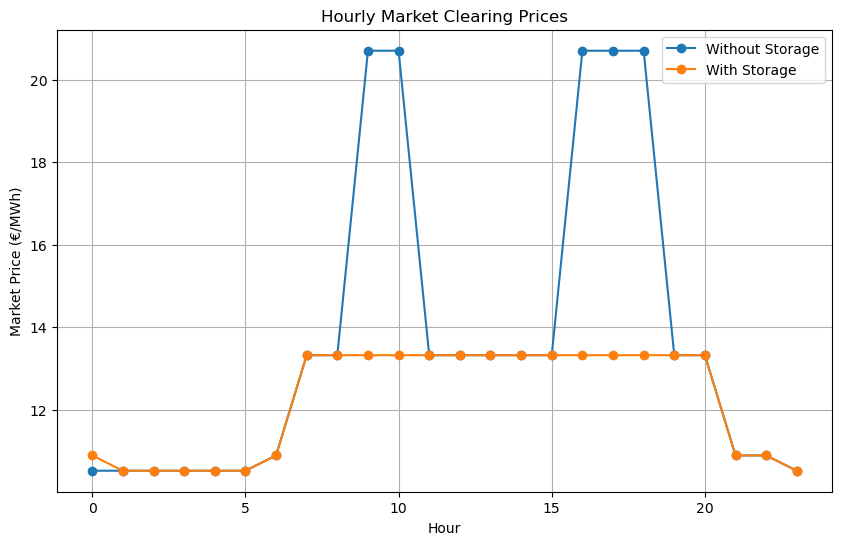

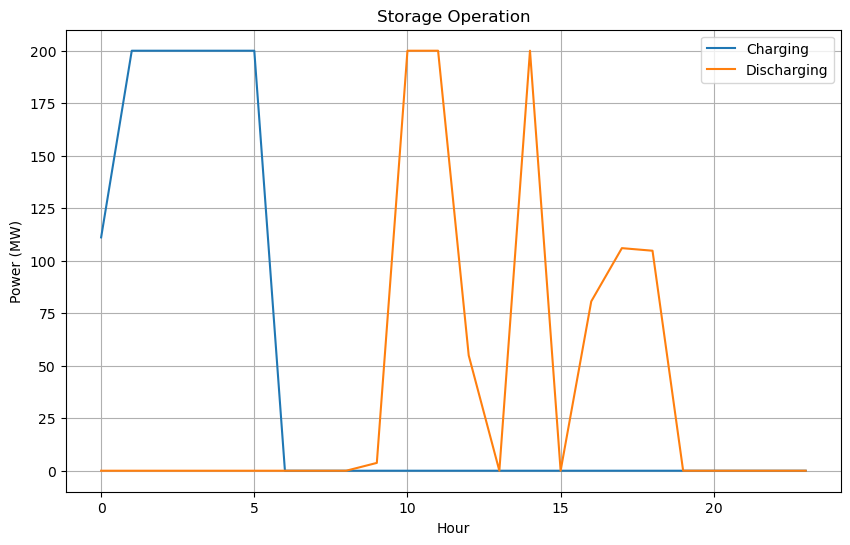

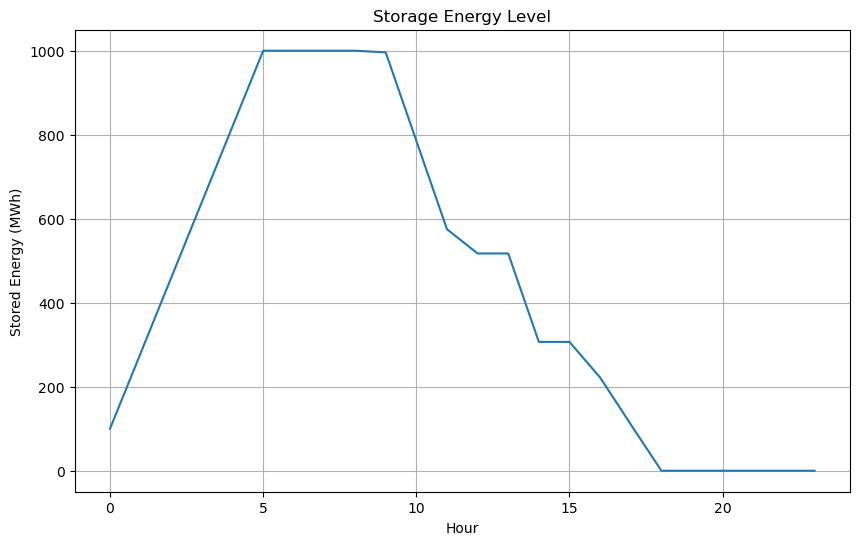

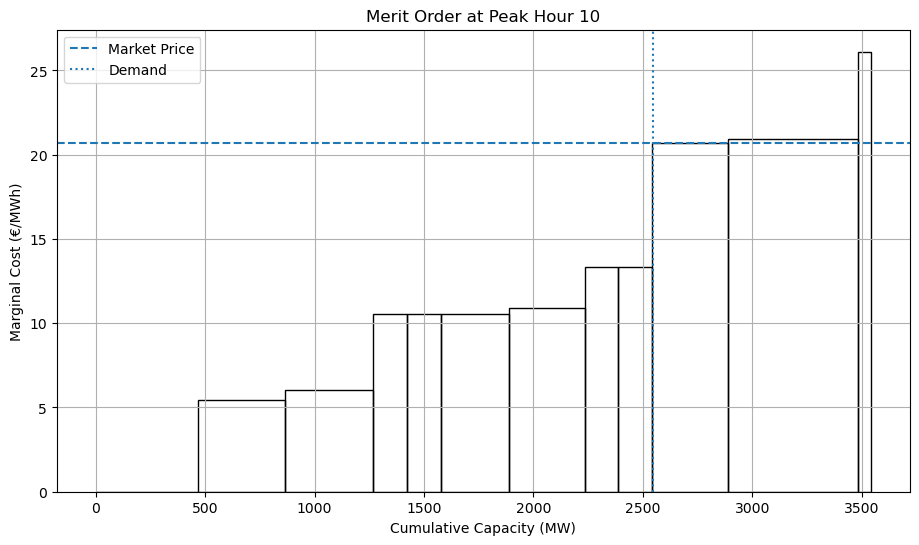

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

hours = list(T)

# ============================================
# Price comparison (with vs without storage)
# ============================================

plt.figure(figsize=(10,6))

plt.plot(hours,
         [lambda_ns[t] for t in T],
         label="Without Storage",
         marker='o')

plt.plot(hours,
         [lambda_s[t] for t in T],
         label="With Storage",
         marker='o')

plt.xlabel("Hour")
plt.ylabel("Market Price (€/MWh)")
plt.title("Hourly Market Clearing Prices")
plt.legend()
plt.grid(True)
plt.show()


# ============================================
# Storage charging / discharging behavior
# ============================================

plt.figure(figsize=(10,6))

plt.plot(hours,
         [p_ch_s[t].X for t in T],
         label="Charging")

plt.plot(hours,
         [p_dis_s[t].X for t in T],
         label="Discharging")

plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title("Storage Operation")
plt.legend()
plt.grid(True)
plt.show()


# ============================================
# Storage energy level (State of Charge)
# ============================================

# You must also return e from solve_model if you want this.
# Assuming you added e_s in the return:

# model_s, lambda_s, p_i_s, p_w_s, d_d_s, p_dis_s, p_ch_s, e_s = solve_model(True)

plt.figure(figsize=(10,6))
plt.plot(hours, [e_s[t].X for t in T])
plt.xlabel("Hour")
plt.ylabel("Stored Energy (MWh)")
plt.title("Storage Energy Level")
plt.grid(True)
plt.show()


# ============================================
# Merit order for peak hour (without storage)
# ============================================

peak_hour = max(lambda_ns, key=lambda_ns.get)

lambda_peak = lambda_ns[peak_hour]
D_peak = D_t[peak_hour]
P_w_peak = P_w_bar[peak_hour]

gen_data = pd.DataFrame({
    "unit": [f"G{i}" for i in range(1, 13)],
    "Pmax": [P_max[i] for i in G],
    "cost": [C[i] for i in G]
})

wind_block = pd.DataFrame({
    "unit": ["Wind"],
    "Pmax": [P_w_peak],
    "cost": [0.0]
})

supply_data = pd.concat([wind_block, gen_data], ignore_index=True)
supply_sorted = supply_data.sort_values("cost").reset_index(drop=True)

plt.figure(figsize=(11,6))

cumulative = 0

for i in range(len(supply_sorted)):
    capacity = supply_sorted.loc[i, "Pmax"]
    cost = supply_sorted.loc[i, "cost"]

    plt.bar(cumulative,
            cost,
            width=capacity,
            align='edge',
            edgecolor='black',
            fill=False)

    cumulative += capacity

plt.axhline(lambda_peak, linestyle='--', label="Market Price")
plt.axvline(D_peak, linestyle=':', label="Demand")

plt.xlabel("Cumulative Capacity (MW)")
plt.ylabel("Marginal Cost (€/MWh)")
plt.title(f"Merit Order at Peak Hour {peak_hour+1}")
plt.legend()
plt.grid(True)
plt.show()
